In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


## Both datasets are already clean so I'll just load and merge them and start working

In [118]:
products = pd.read_csv("products.csv")
products.head()

,ProductID,ProductName,Category,SubCategory,UnitCost,UnitPrice,SupplierName
0,PROD0001,Headphones,Electronics,Headphones,850.13,1466.86,Massmart Group
1,PROD0002,Bluetooth Speaker,Electronics,Bluetooth Speaker,410.85,746.98,Massmart Group
2,PROD0003,Smartphone Case,Electronics,Smartphone Case,669.04,1220.01,Makro Wholesale
3,PROD0004,Power Bank,Electronics,Power Bank,109.45,236.83,Local SA Traders
4,PROD0005,USB-C Cable,Electronics,USB-C Cable,540.80,686.66,Builders Warehouse


In [119]:
Sales = pd.read_csv("sales.csv")
Sales.head()

,SaleID,OrderID,ProductID,Quantity,UnitPrice,Discount,LineTotal
0,SALE00001,ORD00001,PROD0009,4,1602.75,0.15,5449.35
1,SALE00002,ORD00001,PROD0028,6,1307.92,0.00,7847.52
2,SALE00003,ORD00001,PROD0011,3,169.74,0.05,483.76
3,SALE00004,ORD00002,PROD0008,2,339.36,0.00,678.72
4,SALE00005,ORD00002,PROD0003,5,1220.01,0.00,6100.05


In [120]:
ProductsSales = pd.merge(products, Sales, on='ProductID', how='inner', suffixes=('_product', '_sales'))
ProductsSales.head()

,ProductID,ProductName,Category,SubCategory,UnitCost,UnitPrice_product,SupplierName,SaleID,OrderID,Quantity,UnitPrice_sales,Discount,LineTotal
0,PROD0001,Headphones,Electronics,Headphones,850.13,1466.86,Massmart Group,SALE00025,ORD00013,1,1466.86,0.0,1466.86
1,PROD0001,Headphones,Electronics,Headphones,850.13,1466.86,Massmart Group,SALE00031,ORD00015,3,1466.86,0.0,4400.58
2,PROD0001,Headphones,Electronics,Headphones,850.13,1466.86,Massmart Group,SALE00046,ORD00021,3,1466.86,0.0,4400.58
3,PROD0001,Headphones,Electronics,Headphones,850.13,1466.86,Massmart Group,SALE00061,ORD00028,4,1466.86,0.0,5867.44
4,PROD0001,Headphones,Electronics,Headphones,850.13,1466.86,Massmart Group,SALE00065,ORD00030,2,1466.86,0.1,2640.35


## Investigating the merge

In [121]:
print("The shape of the merged dataset is:", ProductsSales.shape)
print("The data types of the columns in the merged dataset are:", ProductsSales.dtypes)
print("Nulls after merging:", ProductsSales.isnull().sum())

The shape of the merged dataset is: (1217, 13)
The data types of the columns in the merged dataset are: ProductID             object
ProductName           object
Category              object
SubCategory           object
UnitCost             float64
UnitPrice_product    float64
SupplierName          object
SaleID                object
OrderID               object
Quantity               int64
UnitPrice_sales      float64
Discount             float64
LineTotal            float64
dtype: object
Nulls after merging: ProductID            0
ProductName          0
Category             0
SubCategory          0
UnitCost             0
UnitPrice_product    0
SupplierName         0
SaleID               0
OrderID              0
Quantity             0
UnitPrice_sales      0
Discount             0
LineTotal            0
dtype: int64


In [122]:
mismatched_rows = (ProductsSales['UnitPrice_sales'] != ProductsSales['UnitPrice_product']).sum()
print("Number of mismatched rows in UnitPrice:", mismatched_rows)

Number of mismatched rows in UnitPrice: 0


In [123]:
ProductsSales = ProductsSales.drop_duplicates(subset=['ProductID', 'UnitPrice_sales'], keep='first')

In [124]:
ProductsSales = ProductsSales.drop(columns=['UnitPrice_product'])
ProductsSales = ProductsSales.rename(columns={'UnitPrice_sales': 'UnitPrice'})

## Correlation


In [125]:
ProductsSales['Margin'] = ProductsSales['UnitPrice'] - ProductsSales['UnitCost']

In [126]:
ProductsSales.corr(numeric_only=True)

,UnitCost,Quantity,UnitPrice,Discount,LineTotal,Margin
UnitCost,1.000000,0.326685,0.943350,0.174313,0.710063,0.754986
Quantity,0.326685,1.000000,0.301585,0.367444,0.812530,0.233612
UnitPrice,0.943350,0.301585,1.000000,0.354080,0.719367,0.929791
Discount,0.174313,0.367444,0.354080,1.000000,0.343403,0.506397
LineTotal,0.710063,0.812530,0.719367,0.343403,1.000000,0.633972
Margin,0.754986,0.233612,0.929791,0.506397,0.633972,1.000000


In [127]:


ProductsSales["Revenue"] = ProductsSales["UnitPrice"] * ProductsSales["Quantity"]
ProductsSales["TotalCost"] = ProductsSales["UnitCost"] * ProductsSales["Quantity"]
ProductsSales["Profit"] = ProductsSales["Revenue"] - ProductsSales["TotalCost"]



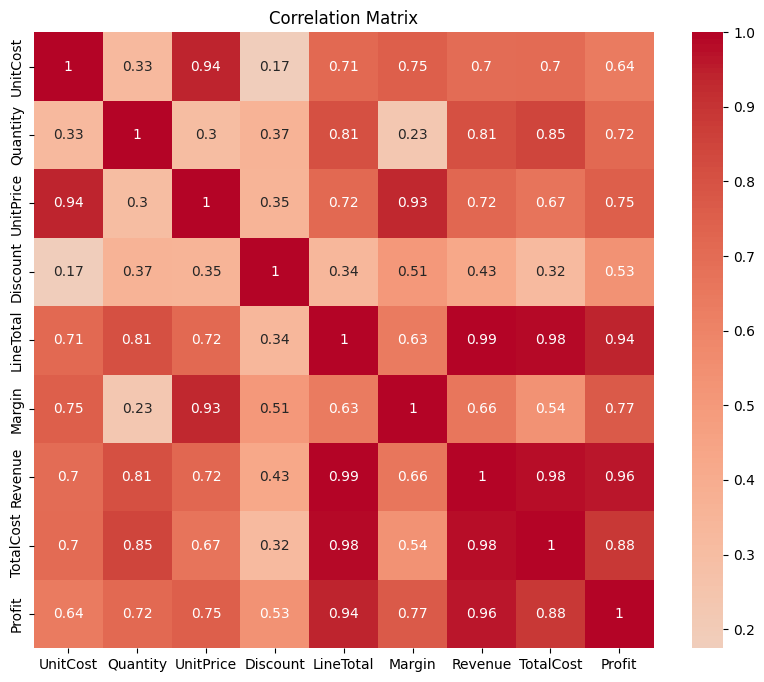

In [128]:
corr_matrix = ProductsSales.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

## Regression (predicting linetotal)

In [129]:
x = ProductsSales[['Quantity', 'UnitPrice',  'UnitCost']]
y = ProductsSales['LineTotal']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)
print("R-squared:", r2_score(y_test, y_pred))

Slope (Coefficient): 890.5165654070731
Intercept: -2314.9965384189145
R-squared: 0.8518225008832352


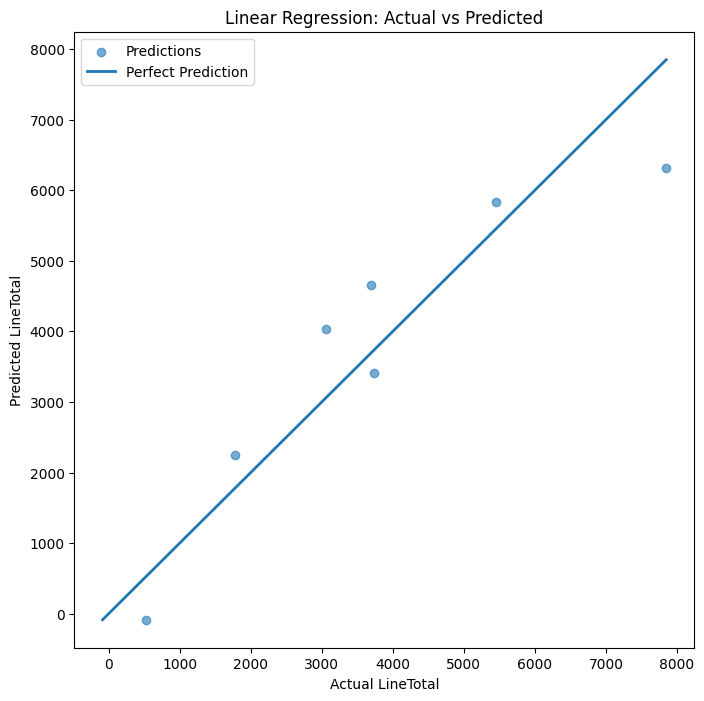

In [130]:
plt.figure(figsize=(8, 8))

# Make sure both are 1-dimensional
actual = y_test.to_numpy().ravel()
predicted = y_pred.ravel()

# Actual vs predicted
plt.scatter(actual, predicted, alpha=0.6, label='Predictions')

# Perfect prediction line
min_value = min(actual.min(), predicted.min())
max_value = max(actual.max(), predicted.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel('Actual LineTotal')
plt.ylabel('Predicted LineTotal')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.show()

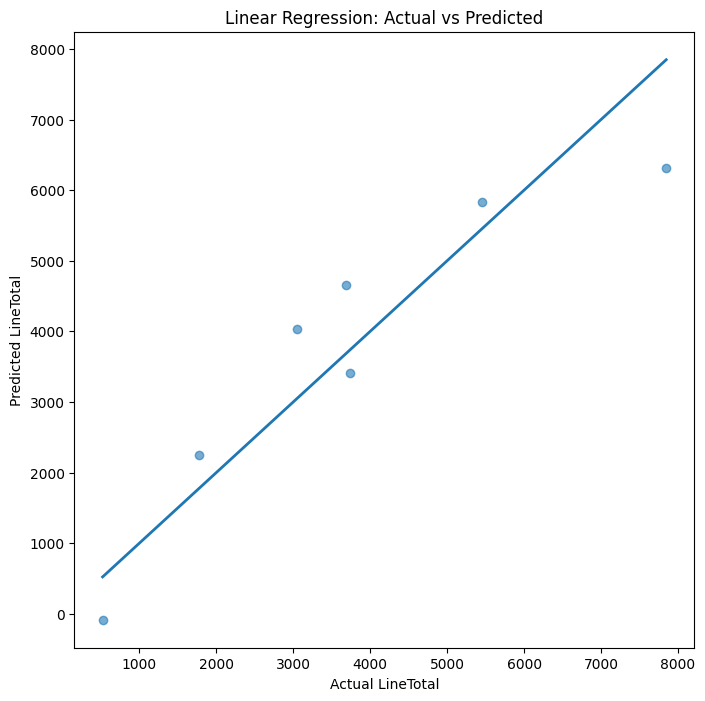

In [131]:
plt.figure(figsize=(8, 8))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel('Actual LineTotal')
plt.ylabel('Predicted LineTotal')
plt.title('Linear Regression: Actual vs Predicted')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.show()

## Prediction

In [132]:
ProductsSales['PredictedLineTotal'] = model.predict(ProductsSales[['Quantity', 'UnitPrice', 'UnitCost']])

comparison = ProductsSales[['Quantity','UnitPrice', 'UnitCost',  'LineTotal', 'PredictedLineTotal']].copy()
comparison['Difference'] = comparison['LineTotal'] - comparison['PredictedLineTotal']

print("Comparison of Actual and Predicted LineTotal:\n", comparison.head())

Comparison of Actual and Predicted LineTotal:
      Quantity  UnitPrice  UnitCost  LineTotal  PredictedLineTotal   Difference
0           1    1466.86    850.13    1466.86         2485.793676 -1018.933676
47          1     746.98    410.85     709.63          602.913335   106.716665
84          5    1220.01    669.04    6100.05         5452.087610   647.962390
121         1     236.83    109.45     236.83         -747.619267   984.449267
164         1     686.66    540.80     652.33          172.082610   480.247390


In [133]:
ProductsSales.to_csv("ProductsSales.csv", index=False)